In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import shutil
import string
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras import losses

In [372]:
embedding_dim = 50  # GloVe 50d
vocab = vectorize_layer.get_vocabulary()
embedding_index = {}

with open('/content/sample_data/pretrain/glove.6B.50d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.random.normal(size=(len(vocab), embedding_dim)).astype(np.float32)

for i, word in enumerate(vocab):
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [373]:
batch_size = 32
seed = 42
max_features = 10000
sequence_length = 250

train_data = pd.read_csv("/content/sample_data/train/train_subset.csv")
test_data = pd.read_csv("/content/sample_data/test/test.csv")

train_data["text"] = (train_data["Title"] + " " + train_data["Description"]).astype(str)
test_data["text"] = (test_data["Title"] + " " + test_data["Description"]).astype(str)

train_data = train_data.sample(frac=1, random_state=seed)

train_size = int(0.8 * len(train_data))
val_data = train_data[train_size:]
train_data = train_data[:train_size]

train_data["Class Index"] -= 1
val_data["Class Index"] -= 1
test_data["Class Index"] -= 1

raw_train_ds = tf.data.Dataset.from_tensor_slices((train_data["text"].values, train_data["Class Index"].values))
raw_val_ds = tf.data.Dataset.from_tensor_slices((val_data["text"].values, val_data["Class Index"].values))
raw_test_ds = tf.data.Dataset.from_tensor_slices((test_data["text"].values, test_data["Class Index"].values))

raw_train_ds = raw_train_ds.batch(batch_size)
raw_val_ds = raw_val_ds.batch(batch_size)
raw_test_ds = raw_test_ds.batch(batch_size)


# for text_batch, label_batch in raw_train_ds.take(1):
#     print("text_batch shape:", text_batch.shape)  # (32,)
#     print("label_batch shape:", label_batch.shape)
#     print("text_batch:", text_batch)


In [374]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [375]:
vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [376]:
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)


In [377]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [378]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.shuffle(10000).map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = raw_test_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)


In [379]:
for x, y in train_ds.take(1):
    print(x.shape)

(32, 250)


In [380]:
embedding_layer = layers.Embedding(
    input_dim=len(vocab),
    output_dim=embedding_dim,
    embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
    trainable=True,
)

In [381]:
embedding_dim = 16

model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,), dtype=tf.int32),
    embedding_layer,
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_41 (Embedding)        │ (None, 250, 50)        │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 246, 128)       │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_41     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,160 (141.25 KB)

 Trainable params: 36,160 (141.25 KB)

 Non-trainable params: 0 (0.00 B)

In [382]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [383]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2499 - loss: 1.3870 - val_accuracy: 0.2575 - val_loss: 1.3833
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2705 - loss: 1.3819 - val_accuracy: 0.2825 - val_loss: 1.3768
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2875 - loss: 1.3760 - val_accuracy: 0.3738 - val_loss: 1.3316
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3604 - loss: 1.3263 - val_accuracy: 0.3713 - val_loss: 1.2998
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3811 - loss: 1.2906 - val_accuracy: 0.3900 - val_loss: 1.2682
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3907 - loss: 1.2647 - val_accuracy: 0.4075 - val_loss: 1.2391
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4158 - loss: 1.2351 - val_accuracy: 0.4471 - val_loss: 1.2042
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4520 - loss: 1.1933 - val_accuracy: 0.

In [384]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5468 - loss: 1.0478
Loss:  1.0724080801010132
Accuracy:  0.5346052646636963


In [385]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━

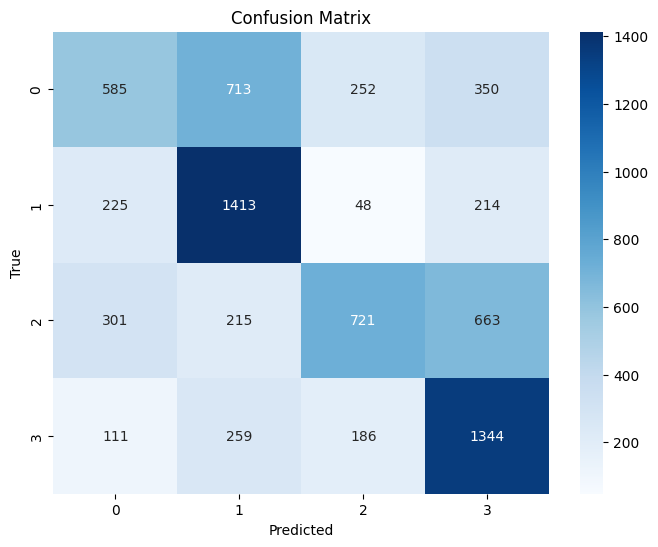

In [386]:
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch)
    preds = np.argmax(preds, axis=1)
    y_pred.extend(preds)
    y_true.extend(y_batch.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

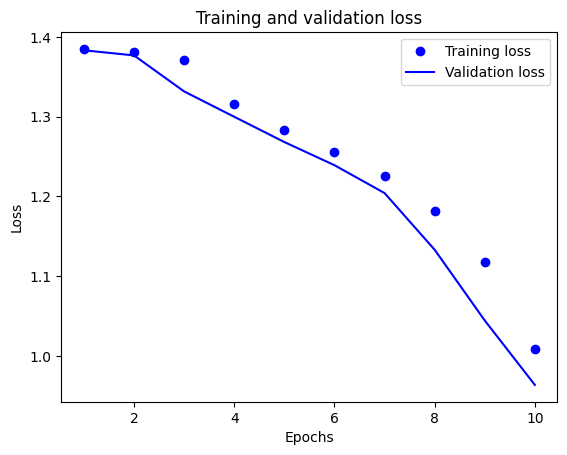

In [387]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

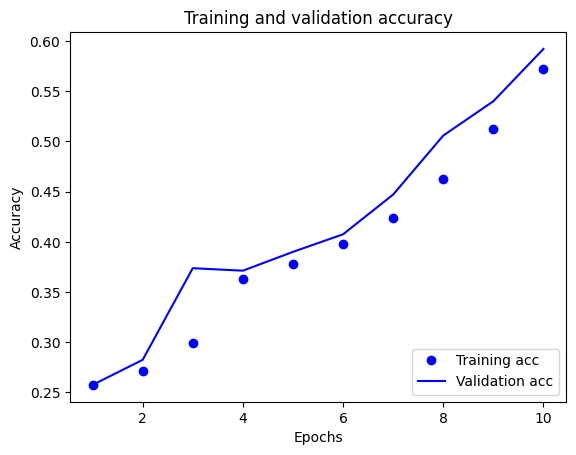

In [388]:

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()